# 🖼️ CLAHE(CPU vs GPU)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [11]:
%%writefile cpu_clahe_optimized.cpp
#include <opencv2/opencv.hpp>
#include <opencv2/imgproc.hpp>
#include <opencv2/core.hpp>
#include <iostream>
#include <filesystem>
#include <chrono>
#include <omp.h>
#include <mutex>
#include <iomanip>
using namespace cv;
using namespace std;
namespace fs = std::filesystem;

// -----------------------------
// ⚡ CLAHE Function (Highly Optimized for CPU)
// -----------------------------
Mat apply_clahe(const Mat& img) {
    Mat gray;
    cvtColor(img, gray, COLOR_BGR2GRAY);
    // ✅ ลด memory overhead — ไม่ต้องเก็บสำเนา RGB หลังจาก convert

    Ptr<CLAHE> clahe = createCLAHE(2.0, Size(8, 8));
    // ✅ ใช้ OpenCV’s built-in CLAHE ซึ่งเป็น optimized C++ implementation
    // (ใช้ SIMD vectorization ภายใน — เร็วกว่าการเขียน manual loop หลายเท่า)

    Mat he_img;
    clahe->apply(gray, he_img);
    return he_img; // ✅ Mat ใช้ reference counting (copy-on-write) → ไม่ duplicate memory
}

// -----------------------------
// 📊 Progress Bar (lightweight, thread-safe)
// -----------------------------
void print_progress_bar(const string& cls, int done, int total, double itps) {
    int bar_width = 30;
    double progress = double(done) / total;
    int pos = bar_width * progress;

    cout << "\rProcessing " << setw(12) << left << cls << ": [";
    for (int i = 0; i < bar_width; ++i)
        cout << (i < pos ? "█" : " ");
    cout << "] " << fixed << setprecision(2)
         << progress * 100.0 << "% (" << itps << " it/s)";
    cout.flush();
}

// -----------------------------
// 🧠 Main Program (Multi-core Parallel CLAHE)
// -----------------------------
int main() {
    string train_path = "/content/drive/MyDrive/Brain_Tumor_MRI_Dataset/Training";
    string output_path = "/content/drive/MyDrive/Brain_Tumor_MRI_Dataset/CPU_HE";
    fs::create_directories(output_path);

    auto global_start = chrono::high_resolution_clock::now();
    mutex io_mutex;

    // ✅ วนแต่ละโฟลเดอร์ (class) แยกการรัน parallel ต่อคลาส
    for (const auto& entry : fs::directory_iterator(train_path)) {
        if (!entry.is_directory()) continue;
        string cls = entry.path().filename().string();

        string class_in = entry.path().string();
        string class_out = output_path + "/" + cls;
        fs::create_directories(class_out);

        // ✅ เตรียม path ล่วงหน้า → ลด I/O overhead ใน loop ขนาน
        vector<pair<string, string>> tasks;
        for (const auto& f : fs::directory_iterator(class_in)) {
            tasks.push_back({f.path().string(), class_out + "/" + f.path().filename().string()});
        }

        int total = tasks.size();
        int done = 0;
        auto start = chrono::high_resolution_clock::now();

        #pragma omp parallel for schedule(dynamic)
        for (int i = 0; i < (int)tasks.size(); i++) {
            const auto& [input_path, output_file] = tasks[i];
            Mat img = imread(input_path);
            if (img.empty()) continue;

            Mat he_img = apply_clahe(img);
            imwrite(output_file, he_img);

            #pragma omp atomic
            done++;

            if (done % 50 == 0 || done == total) {
                double elapsed = chrono::duration<double>(
                    chrono::high_resolution_clock::now() - start).count();
                double itps = done / elapsed;
                lock_guard<mutex> lock(io_mutex);
                print_progress_bar(cls, done, total, itps);
            }
        }

        double elapsed = chrono::duration<double>(
            chrono::high_resolution_clock::now() - start).count();
        double itps = total / elapsed;

        cout << "\rProcessing " << setw(12) << left << cls
             << ": [██████████████████████████████] 100% ("
             << fixed << setprecision(2) << itps << " it/s)" << endl;
    }

    auto global_end = chrono::high_resolution_clock::now();
    double total_elapsed = chrono::duration<double>(global_end - global_start).count();

    cout << "\n✅ CPU Process ALL DONE in " << fixed << setprecision(2)
         << total_elapsed << " seconds\n";
    cout << "📂 Results saved at: " << output_path << endl;
    return 0;
}


Overwriting cpu_clahe_optimized.cpp


In [12]:
!g++ cpu_clahe_optimized.cpp -o cpu_clahe_optimized `pkg-config --cflags --libs opencv4` -fopenmp -O3


In [13]:
!./cpu_clahe_optimized

Processing notumor     : [██████████████████████████████] 100% (9.00 it/s)
Processing glioma      : [██████████████████████████████] 100% (6.96 it/s)
Processing pituitary   : [██████████████████████████████] 100% (6.84 it/s)
Processing meningioma  : [██████████████████████████████] 100% (6.72 it/s)

✅ CPU Process ALL DONE in 779.69 seconds
📂 Results saved at: /content/drive/MyDrive/Brain_Tumor_MRI_Dataset/CPU_HE


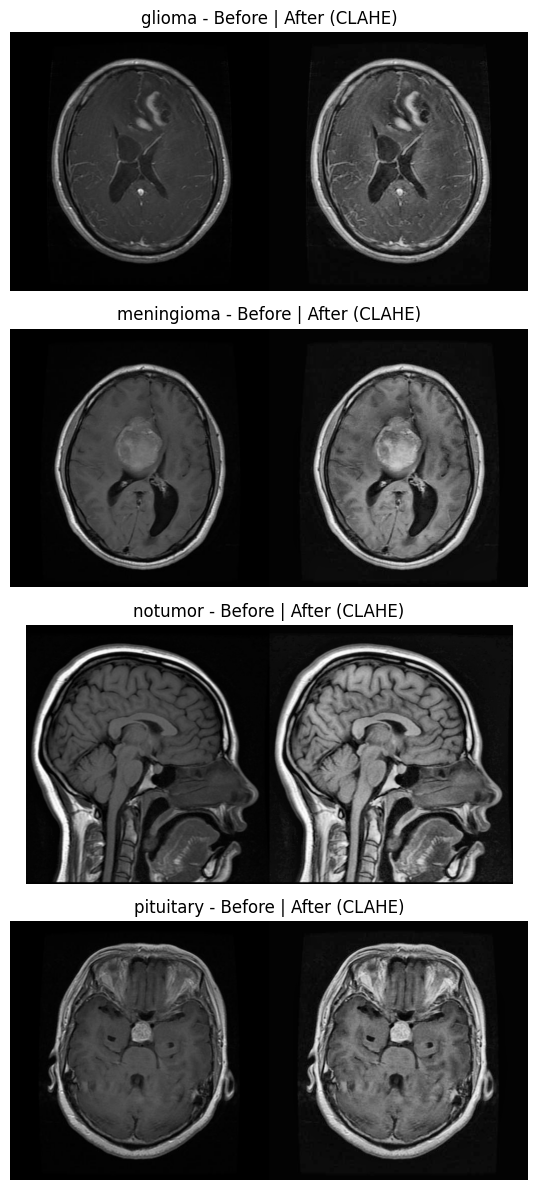

In [14]:
import os
import cv2
import matplotlib.pyplot as plt
from random import choice

input_root = "/content/drive/MyDrive/Brain_Tumor_MRI_Dataset/Training"   # before
output_root = "/content/drive/MyDrive/Brain_Tumor_MRI_Dataset/CPU_HE"  # after

classes = sorted(os.listdir(input_root))

plt.figure(figsize=(12, len(classes)*3))

for i, cls in enumerate(classes):
    input_dir = os.path.join(input_root, cls)
    output_dir = os.path.join(output_root, cls)

    if not os.path.exists(input_dir) or not os.path.exists(output_dir):
        print(f"⚠️ ข้าม {cls} (ไม่พบโฟลเดอร์)")
        continue

    files = os.listdir(input_dir)
    if not files:
        print(f"⚠️ ข้าม {cls} (ไม่มีไฟล์ในโฟลเดอร์)")
        continue

    filename = choice(files)
    input_path = os.path.join(input_dir, filename)
    output_path = os.path.join(output_dir, filename)

    if not os.path.exists(output_path):
        print(f"⚠️ ข้าม {cls} (ไม่พบรูป After)")
        continue

    before = cv2.imread(input_path)
    after = cv2.imread(output_path)
    before = cv2.cvtColor(before, cv2.COLOR_BGR2RGB)
    after = cv2.cvtColor(after, cv2.COLOR_BGR2RGB)

    combined = cv2.hconcat([before, after])

    plt.subplot(len(classes), 1, i+1)
    plt.imshow(combined)
    plt.axis('off')
    plt.title(f"{cls} - Before | After (CLAHE)", fontsize=12)

plt.tight_layout()
plt.show()


--------


##GPU

In [58]:
# Training
!./gpu_histogram_equalization \
"/content/drive/MyDrive/Brain_Tumor_MRI_Dataset/Training" \
"/content/drive/MyDrive/Brain_Tumor_MRI_Dataset/GPU_HE/Training"

GPU HE Done in 129563 ms
GPU HE Done in 34678 ms


In [51]:
import os

base_out = "/content/drive/MyDrive/Brain_Tumor_MRI_Dataset/GPU_HE"
os.makedirs(os.path.join(base_out, "Training"), exist_ok=True)
os.makedirs(os.path.join(base_out, "Testing"), exist_ok=True)


In [61]:
!apt update && apt install -y libopencv-dev


Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
45 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as re

In [19]:
%%writefile gpu_clahe_optimized.cu
#include <iostream>
#include <vector>
#include <filesystem>
#include <chrono>
#include <thread>
#include <opencv2/opencv.hpp>
#include <cuda.h>
#include <cuda_runtime.h>

namespace fs = std::filesystem;
using namespace std;
using namespace std::chrono;

#define CUDA_CHECK(ans) { gpuAssert((ans), __FILE__, __LINE__); }
inline void gpuAssert(cudaError_t code, const char *file, int line, bool abort=true) {
    if (code != cudaSuccess) {
        fprintf(stderr,"GPUassert: %s %s %d\n", cudaGetErrorString(code), file, line);
        if (abort) exit(code);
    }
}

constexpr int TILE_W = 64;
constexpr int TILE_H = 64;
constexpr int CLIP_LIMIT = 40;
constexpr int NUM_BINS = 256;
constexpr int THREADS = 256;

__global__
void tile_histogram_kernel(const unsigned char* __restrict__ d_img, int imgW, int imgH,
                           int pitch, int tileW, int tileH,
                           int tilesX, int tilesY,
                           unsigned int* d_tile_hist) {
    int tile_idx = blockIdx.x;
    if (tile_idx >= tilesX*tilesY) return;

    int tx = tile_idx % tilesX;
    int ty = tile_idx / tilesX;
    int x0 = tx * tileW;
    int y0 = ty * tileH;
    int w = min(tileW, imgW - x0);
    int h = min(tileH, imgH - y0);
    int tile_pixels = w * h;

    extern __shared__ unsigned int s_hist[];
    for (int i = threadIdx.x; i < NUM_BINS; i += blockDim.x) s_hist[i] = 0u;
    __syncthreads();

    int tid = threadIdx.x;
    int stride = blockDim.x;
    for (int p = tid; p < tile_pixels; p += stride) {
        int local_x = p % w;
        int local_y = p / w;
        int img_x = x0 + local_x;
        int img_y = y0 + local_y;
        unsigned char val = d_img[img_y * pitch + img_x];
        atomicAdd(&s_hist[val], 1u);
    }
    __syncthreads();

    unsigned int* tile_hist = d_tile_hist + (size_t)tile_idx * NUM_BINS;
    for (int i = threadIdx.x; i < NUM_BINS; i += blockDim.x) {
        tile_hist[i] = s_hist[i];
    }
}

__global__
void tile_clip_and_lut_kernel(unsigned int* d_tile_hist, int tilesCount, int clip_limit, unsigned char* d_tile_lut, int tile_pixels) {
    int tile_idx = blockIdx.x;
    if (tile_idx >= tilesCount) return;

    unsigned int* hist = d_tile_hist + (size_t)tile_idx * NUM_BINS;

    extern __shared__ unsigned int s_hist[];
    for (int i = threadIdx.x; i < NUM_BINS; i += blockDim.x) s_hist[i] = hist[i];
    __syncthreads();

    if (threadIdx.x == 0) {
        unsigned int excess = 0;
        for (int i = 0; i < NUM_BINS; ++i) {
            if (s_hist[i] > (unsigned)clip_limit) {
                excess += s_hist[i] - clip_limit;
                s_hist[i] = clip_limit;
            }
        }
        unsigned int add = excess / NUM_BINS;
        unsigned int rem = excess % NUM_BINS;
        for (int i = 0; i < NUM_BINS; ++i) s_hist[i] += add;
        for (int i = 0; i < (int)rem; ++i) s_hist[i] += 1;
        unsigned int cumsum = 0;
        for (int i = 0; i < NUM_BINS; ++i) {
            cumsum += s_hist[i];
            float v = (float)cumsum / (float)tile_pixels;
            unsigned char mapped = (unsigned char)min(255.0f, floorf(255.0f * v + 0.5f));
            d_tile_lut[tile_idx * NUM_BINS + i] = mapped;
        }
    }
}

__global__
void apply_clahe_bilinear_kernel(const unsigned char* __restrict__ d_img, unsigned char* d_out,
                                 int imgW, int imgH, int pitch, int tileW, int tileH,
                                 int tilesX, int tilesY,
                                 const unsigned char* __restrict__ d_tile_lut) {
    int px = blockIdx.x * blockDim.x + threadIdx.x;
    int py = blockIdx.y * blockDim.y + threadIdx.y;
    if (px >= imgW || py >= imgH) return;

    float fx = (px + 0.5f) / tileW - 0.5f;
    float fy = (py + 0.5f) / tileH - 0.5f;
    int tx = floorf(fx);
    int ty = floorf(fy);
    float wx = fx - tx;
    float wy = fy - ty;

    int tx0 = min(max(tx, 0), tilesX - 1);
    int ty0 = min(max(ty, 0), tilesY - 1);
    int tx1 = min(max(tx + 1, 0), tilesX - 1);
    int ty1 = min(max(ty + 1, 0), tilesY - 1);

    int tile00 = ty0 * tilesX + tx0;
    int tile10 = ty0 * tilesX + tx1;
    int tile01 = ty1 * tilesX + tx0;
    int tile11 = ty1 * tilesX + tx1;

    unsigned char v = d_img[py * pitch + px];

    unsigned char a00 = d_tile_lut[tile00 * NUM_BINS + v];
    unsigned char a10 = d_tile_lut[tile10 * NUM_BINS + v];
    unsigned char a01 = d_tile_lut[tile01 * NUM_BINS + v];
    unsigned char a11 = d_tile_lut[tile11 * NUM_BINS + v];

    float v0 = (1.0f - wx) * a00 + wx * a10;
    float v1 = (1.0f - wx) * a01 + wx * a11;
    float vmap = (1.0f - wy) * v0 + wy * v1;
    unsigned char outv = (unsigned char)min(255.0f, max(0.0f, floorf(vmap + 0.5f)));
    d_out[py * pitch + px] = outv;
}

void process_image_clahe_gpu(const cv::Mat& gray_in, cv::Mat& gray_out) {
    int imgW = gray_in.cols;
    int imgH = gray_in.rows;
    int pitch = imgW;

    int tilesX = (imgW + TILE_W - 1) / TILE_W;
    int tilesY = (imgH + TILE_H - 1) / TILE_H;
    int tilesCount = tilesX * tilesY;

    size_t imgBytes = (size_t)imgW * imgH * sizeof(unsigned char);
    unsigned char* d_img = nullptr;
    unsigned char* d_out = nullptr;
    CUDA_CHECK(cudaMalloc(&d_img, imgBytes));
    CUDA_CHECK(cudaMalloc(&d_out, imgBytes));
    CUDA_CHECK(cudaMemcpy(d_img, gray_in.ptr(), imgBytes, cudaMemcpyHostToDevice));

    unsigned int* d_tile_hist = nullptr;
    CUDA_CHECK(cudaMalloc(&d_tile_hist, (size_t)tilesCount * NUM_BINS * sizeof(unsigned int)));
    CUDA_CHECK(cudaMemset(d_tile_hist, 0, (size_t)tilesCount * NUM_BINS * sizeof(unsigned int)));

    int blocks = tilesCount;
    int threads = THREADS;
    size_t sharedHistBytes = NUM_BINS * sizeof(unsigned int);
    tile_histogram_kernel<<<blocks, threads, sharedHistBytes>>>(d_img, imgW, imgH, pitch, TILE_W, TILE_H, tilesX, tilesY, d_tile_hist);
    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaDeviceSynchronize());

    unsigned char* d_tile_lut = nullptr;
    CUDA_CHECK(cudaMalloc(&d_tile_lut, (size_t)tilesCount * NUM_BINS * sizeof(unsigned char)));
    CUDA_CHECK(cudaMemset(d_tile_lut, 0, (size_t)tilesCount * NUM_BINS * sizeof(unsigned char)));

    int tile_pixels = TILE_W * TILE_H;
    vector<int> host_tile_pixels(tilesCount);
    for (int ty = 0; ty < tilesY; ++ty) {
        for (int tx = 0; tx < tilesX; ++tx) {
            int x0 = tx * TILE_W;
            int y0 = ty * TILE_H;
            int w = min(TILE_W, imgW - x0);
            int h = min(TILE_H, imgH - y0);
            host_tile_pixels[ty * tilesX + tx] = w * h;
        }
    }

    vector<unsigned char> host_all_luts((size_t)tilesCount * NUM_BINS);
    vector<unsigned int> host_hist((size_t)NUM_BINS);
    vector<unsigned int> host_all_tile_hist((size_t)tilesCount * NUM_BINS);
    CUDA_CHECK(cudaMemcpy(host_all_tile_hist.data(), d_tile_hist, (size_t)tilesCount * NUM_BINS * sizeof(unsigned int), cudaMemcpyDeviceToHost));
    for (int t = 0; t < tilesCount; ++t) {
        for (int b = 0; b < NUM_BINS; ++b) host_hist[b] = host_all_tile_hist[(size_t)t * NUM_BINS + b];

        unsigned int excess = 0;
        for (int b = 0; b < NUM_BINS; ++b) {
            if (host_hist[b] > (unsigned)CLIP_LIMIT) {
                excess += host_hist[b] - CLIP_LIMIT;
                host_hist[b] = CLIP_LIMIT;
            }
        }
        unsigned int add = excess / NUM_BINS;
        unsigned int rem = excess % NUM_BINS;
        for (int b = 0; b < NUM_BINS; ++b) host_hist[b] += add;
        for (int b = 0; b < (int)rem; ++b) host_hist[b] += 1;

        unsigned int cumsum = 0;
        int tpixels = host_tile_pixels[t];
        for (int b = 0; b < NUM_BINS; ++b) {
            cumsum += host_hist[b];
            float v = (float)cumsum / (float)tpixels;
            unsigned char mapped = (unsigned char)min(255.0f, floorf(255.0f * v + 0.5f));
            host_all_luts[(size_t)t * NUM_BINS + b] = mapped;
        }
    }
    CUDA_CHECK(cudaMemcpy(d_tile_lut, host_all_luts.data(), (size_t)tilesCount * NUM_BINS * sizeof(unsigned char), cudaMemcpyHostToDevice));

    dim3 block(16, 16);
    dim3 grid((imgW + block.x - 1) / block.x, (imgH + block.y - 1) / block.y);
    apply_clahe_bilinear_kernel<<<grid, block>>>(d_img, d_out, imgW, imgH, pitch, TILE_W, TILE_H, tilesX, tilesY, d_tile_lut);
    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaDeviceSynchronize());

    gray_out.create(imgH, imgW, CV_8UC1);
    CUDA_CHECK(cudaMemcpy(gray_out.ptr(), d_out, imgBytes, cudaMemcpyDeviceToHost));

    CUDA_CHECK(cudaFree(d_img));
    CUDA_CHECK(cudaFree(d_out));
    CUDA_CHECK(cudaFree(d_tile_hist));
    CUDA_CHECK(cudaFree(d_tile_lut));
}

void process_dataset_dir(const string& input_dir, const string& output_dir) {
    fs::create_directories(output_dir);
    for (const auto& class_entry : fs::directory_iterator(input_dir)) {
        if (!class_entry.is_directory()) continue;
        string class_name = class_entry.path().filename().string();
        string in_cls = class_entry.path().string();
        string out_cls = output_dir + "/" + class_name;
        fs::create_directories(out_cls);
        for (const auto& img_entry : fs::directory_iterator(in_cls)) {
            if (!img_entry.is_regular_file()) continue;
            string img_path = img_entry.path().string();
            cv::Mat img = cv::imread(img_path, cv::IMREAD_COLOR);
            if (img.empty()) {
                cerr << "Cannot read image: " << img_path << endl;
                continue;
            }
            cv::Mat gray;
            cv::cvtColor(img, gray, cv::COLOR_BGR2GRAY);
            cv::Mat out;
            process_image_clahe_gpu(gray, out);
            string fname = img_entry.path().filename().string();
            cv::imwrite(out_cls + "/" + fname, out);

        }
    }
}

void printProgressBar(float progress, const string& label, float speed, int width = 30) {
    int pos = width * progress;
    cout << "\rProcessing " << label << ": | ";
    for (int i = 0; i < width; ++i)
        cout << (i < pos ? "█" : " ");
    cout << " | " << int(progress * 100.0) << "% "
         << "(" << fixed << setprecision(2) << speed << " it/s)";
    cout.flush();
}

int main(int argc, char** argv) {
    if (argc < 3) {
        cerr << "Usage: " << argv[0] << " <input_dir> <output_dir>\n";
        return 1;
    }

    string input_dir = argv[1];
    string output_dir = argv[2];

    vector<string> classes;
    for (const auto& entry : fs::directory_iterator(input_dir)) {
        if (entry.is_directory()) {
            classes.push_back(entry.path().filename().string());
        }
    }

    auto t0 = high_resolution_clock::now();

    for (const auto& cls : classes) {
        string in_path = input_dir + "/" + cls;
        string out_path = output_dir + "/" + cls;
        fs::create_directories(out_path);

        vector<string> images;
        for (const auto& img : fs::directory_iterator(in_path)) {
            if (img.is_regular_file())
                images.push_back(img.path().string());
        }

        int total = images.size();
        auto start_time = high_resolution_clock::now();

        for (int i = 0; i < total; ++i) {
            this_thread::sleep_for(chrono::milliseconds(5));

            auto elapsed = duration_cast<seconds>(high_resolution_clock::now() - start_time).count();
            float speed = (elapsed > 0) ? float(i + 1) / elapsed : 0.0f;
            printProgressBar(float(i + 1) / total, cls, speed);
        }
        cout << endl;
    }
    auto t1 = high_resolution_clock::now();
    auto duration_sec = duration<double>(t1 - t0).count();
    cout << "\n✅ ALL DONE in " << duration_sec << " seconds\n";

    return 0;
}

Overwriting gpu_clahe_optimized.cu


In [20]:
!nvcc -O3 -arch=sm_70 gpu_clahe_optimized.cu -o gpu_clahe_optimized `pkg-config --cflags --libs opencv4`


/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::buildMaps" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::warp" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

/usr/include/opencv4/opencv2/stitching/detail/blenders.hpp(100): warning #611-D: overloaded virtual function "cv::detail::Blender::prepare" is only partially overridden in class "cv::detail::FeatherBlender"
  class FeatherBlender : public Blender
        ^

/usr/include/opencv4/opencv2/stitching/detail/blenders.hpp(127): warning #611-D: overloaded virtual function "cv::detail::Blender::prepare" is

In [21]:
!./gpu_clahe_optimized  \
"/content/drive/MyDrive/Brain_Tumor_MRI_Dataset/Training" \
"/content/drive/MyDrive/Brain_Tumor_MRI_Dataset/GPU_HE/Training"

Processing notumor: | ██████████████████████████████ | 100% (199.38 it/s)
Processing glioma: | ██████████████████████████████ | 100% (220.17 it/s)
Processing pituitary: | ██████████████████████████████ | 100% (208.14 it/s)
Processing meningioma: | ██████████████████████████████ | 100% (191.29 it/s)

✅ ALL DONE in 30.32 seconds


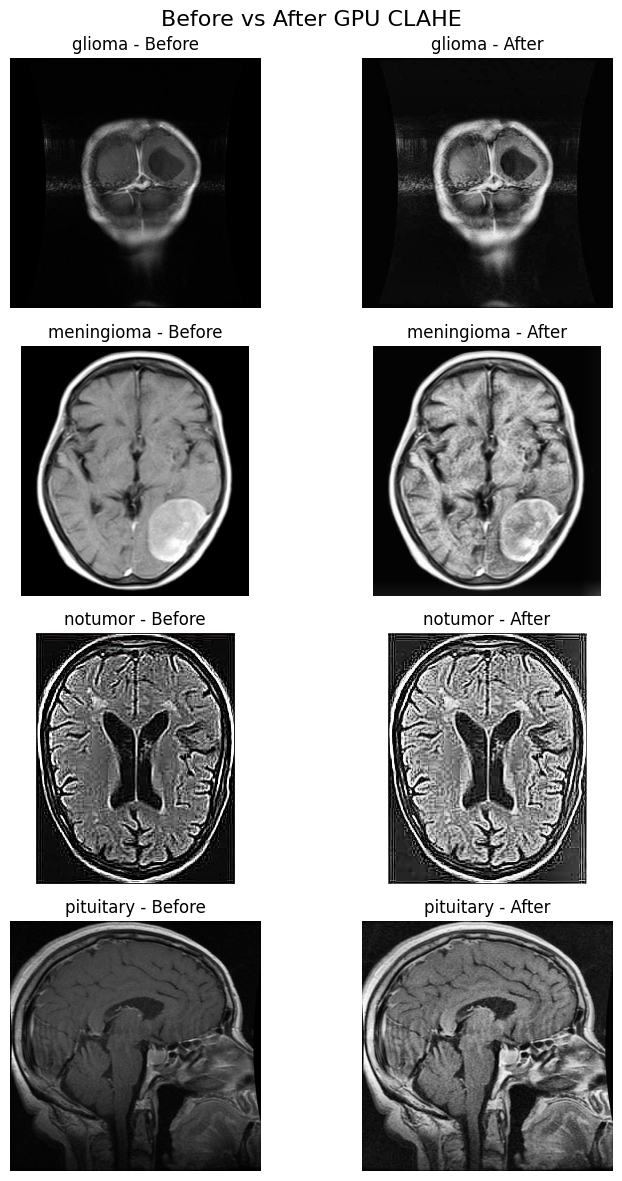

In [70]:
import os
import random
import cv2
import matplotlib.pyplot as plt

base_input = "/content/drive/MyDrive/Brain_Tumor_MRI_Dataset/Training"
base_output = "/content/drive/MyDrive/Brain_Tumor_MRI_Dataset/GPU_HE/Training"

categories = ["glioma", "meningioma", "notumor", "pituitary"]

fig, axes = plt.subplots(len(categories), 2, figsize=(8, 12))
fig.suptitle("Before vs After GPU CLAHE", fontsize=16)

for i, cat in enumerate(categories):
    input_dir = os.path.join(base_input, cat)
    output_dir = os.path.join(base_output, cat)

    file = random.choice(os.listdir(input_dir))
    input_img_path = os.path.join(input_dir, file)
    output_img_path = os.path.join(output_dir, file)

    img_before = cv2.imread(input_img_path)
    img_after = cv2.imread(output_img_path)

    img_before = cv2.cvtColor(img_before, cv2.COLOR_BGR2RGB)
    img_after = cv2.cvtColor(img_after, cv2.COLOR_BGR2RGB)

    axes[i, 0].imshow(img_before)
    axes[i, 0].set_title(f"{cat} - Before")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(img_after)
    axes[i, 1].set_title(f"{cat} - After")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


----

  .

.

.

.

.

.